# A Comparative Study of Population and Sample-Based Decision Making Using Census Data

## Objective 
To analyze census data using statistical sampling techniques and validate results using confidence intervals and the Central Limit Theorem.

### Techniques Used:
- Data Cleaning & Preprocessing
- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling
- Error Analysis
- Confidence Intervals
- Central Limit Theorem (CLT)


## Dataset Description

The dataset used in this project is based on the **India Census 2011**, which provides detailed demographic and socio-economic information at the district level.

### Key Features of the Dataset:
- Covers multiple districts across all Indian states
- Contains population statistics, gender distribution, and workforce data
- Enables analysis of literacy, gender balance, and employment patterns

### Purpose of Dataset:
The dataset is used to:
- Analyze population characteristics
- Apply statistical sampling techniques
- Compare sample estimates with actual population values
- Validate statistical concepts like Confidence Interval and CLT

## Important Column Analysis

### 1 | Population
- Represents total number of people in a district
- Used as a base for calculating other metrics
- Helps identify high-density regions

Insight:
States like Uttar Pradesh and Maharashtra contribute significantly to total population

---

### 2 | Literate
- Number of people who can read and write
- Used to calculate Literacy Rate

Derived Metric:
Literacy Rate = (Literate / Population) × 100

Insight:
Higher literacy indicates better education and development

---

### 3 | Literacy Rate (Derived)
- Percentage of literate population
- Key indicator of education level

Insight:
Most districts fall between 50%–80% literacy range

---

### 4 | Male & Female
- Total male and female population
- Used to calculate Sex Ratio

Derived Metric:
Sex Ratio = (Female / Male) × 1000

 Insight:
Sex ratio below 1000 indicates gender imbalance

---

### 5 | Sex Ratio (Derived)
- Number of females per 1000 males
- Important indicator of gender equality

Insight:
Some districts show significant gender disparity

---

### 6 |  Workers
- Total working population
- Indicates economic activity in a region

Insight:
Higher worker count reflects stronger economic participation

---

### 7 |  State Name & District Name
- Categorical columns used for grouping and analysis
- Helps in regional comparisons

Insight:
Allows identification of top-performing or underdeveloped regions

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 2. Load Dataset

In [2]:
df = pd.read_csv("india_census_2011.csv")
df.head()

,District code,State name,District name,Population,Male,Female,Literate,Male_Literate,Female_Literate,SC,...,Power_Parity_Rs_90000_150000,Power_Parity_Rs_45000_150000,Power_Parity_Rs_150000_240000,Power_Parity_Rs_240000_330000,Power_Parity_Rs_150000_330000,Power_Parity_Rs_330000_425000,Power_Parity_Rs_425000_545000,Power_Parity_Rs_330000_545000,Power_Parity_Above_Rs_545000,Total_Power_Parity
0,1,JAMMU AND KASHMIR,Kupwara,870354,474190,396164,439654,282823,156831,1048,...,94,588,71,101,172,74,10,84,15,1119
1,2,JAMMU AND KASHMIR,Badgam,753745,398041,355704,335649,207741,127908,368,...,126,562,72,89,161,96,28,124,18,1066
2,3,JAMMU AND KASHMIR,Leh(Ladakh),133487,78971,54516,93770,62834,30936,488,...,46,122,15,22,37,20,14,34,17,242
3,4,JAMMU AND KASHMIR,Kargil,140802,77785,63017,86236,56301,29935,18,...,27,114,12,18,30,19,3,22,7,214
4,5,JAMMU AND KASHMIR,Punch,476835,251899,224936,261724,163333,98391,556,...,78,346,35,50,85,59,8,67,12,629


## 3. Clean Column Names
Standardizing column names for consistency

In [3]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('_', ' ')
df.columns = df.columns.str.title()

print(df.columns)

Index(['District Code', 'State Name', 'District Name', 'Population', 'Male',
       'Female', 'Literate', 'Male Literate', 'Female Literate', 'Sc',
       ...
       'Power Parity Rs 90000 150000', 'Power Parity Rs 45000 150000',
       'Power Parity Rs 150000 240000', 'Power Parity Rs 240000 330000',
       'Power Parity Rs 150000 330000', 'Power Parity Rs 330000 425000',
       'Power Parity Rs 425000 545000', 'Power Parity Rs 330000 545000',
       'Power Parity Above Rs 545000', 'Total Power Parity'],
      dtype='object', length=118)


## 4. Data Cleaning
Handling missing values and duplicates

In [4]:
df = df.dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Columns: 118 entries, District Code to Total Power Parity
dtypes: int64(116), object(2)
memory usage: 590.1+ KB


## 5. Feature Engineering
Creating new meaningful features

In [5]:
# Literacy Rate
df['Literacy Rate'] = (df['Literate'] / df['Population']) * 100

In [6]:
# Sex Ratio
df['Sex Ratio'] = (df['Female'] / df['Male']) * 1000

In [7]:
# Workers
if 'Workers' not in df.columns:
    df['Workers'] = df['Main Workers'] + df['Marginal Workers']

## 6. Selecting Relevant Columns

In [8]:
df = df[['State Name', 'District Name', 'Population',
         'Literacy Rate', 'Sex Ratio', 'Workers']]

df.head()

,State Name,District Name,Population,Literacy Rate,Sex Ratio,Workers
0,JAMMU AND KASHMIR,Kupwara,870354,50.514388,835.454143,229064
1,JAMMU AND KASHMIR,Badgam,753745,44.530843,893.636585,214866
2,JAMMU AND KASHMIR,Leh(Ladakh),133487,70.246541,690.329361,75079
3,JAMMU AND KASHMIR,Kargil,140802,61.246289,810.143344,51873
4,JAMMU AND KASHMIR,Punch,476835,54.887749,892.961068,161393


## 7. Exploratory Analysis of Population, Literacy, and Gender Metrics

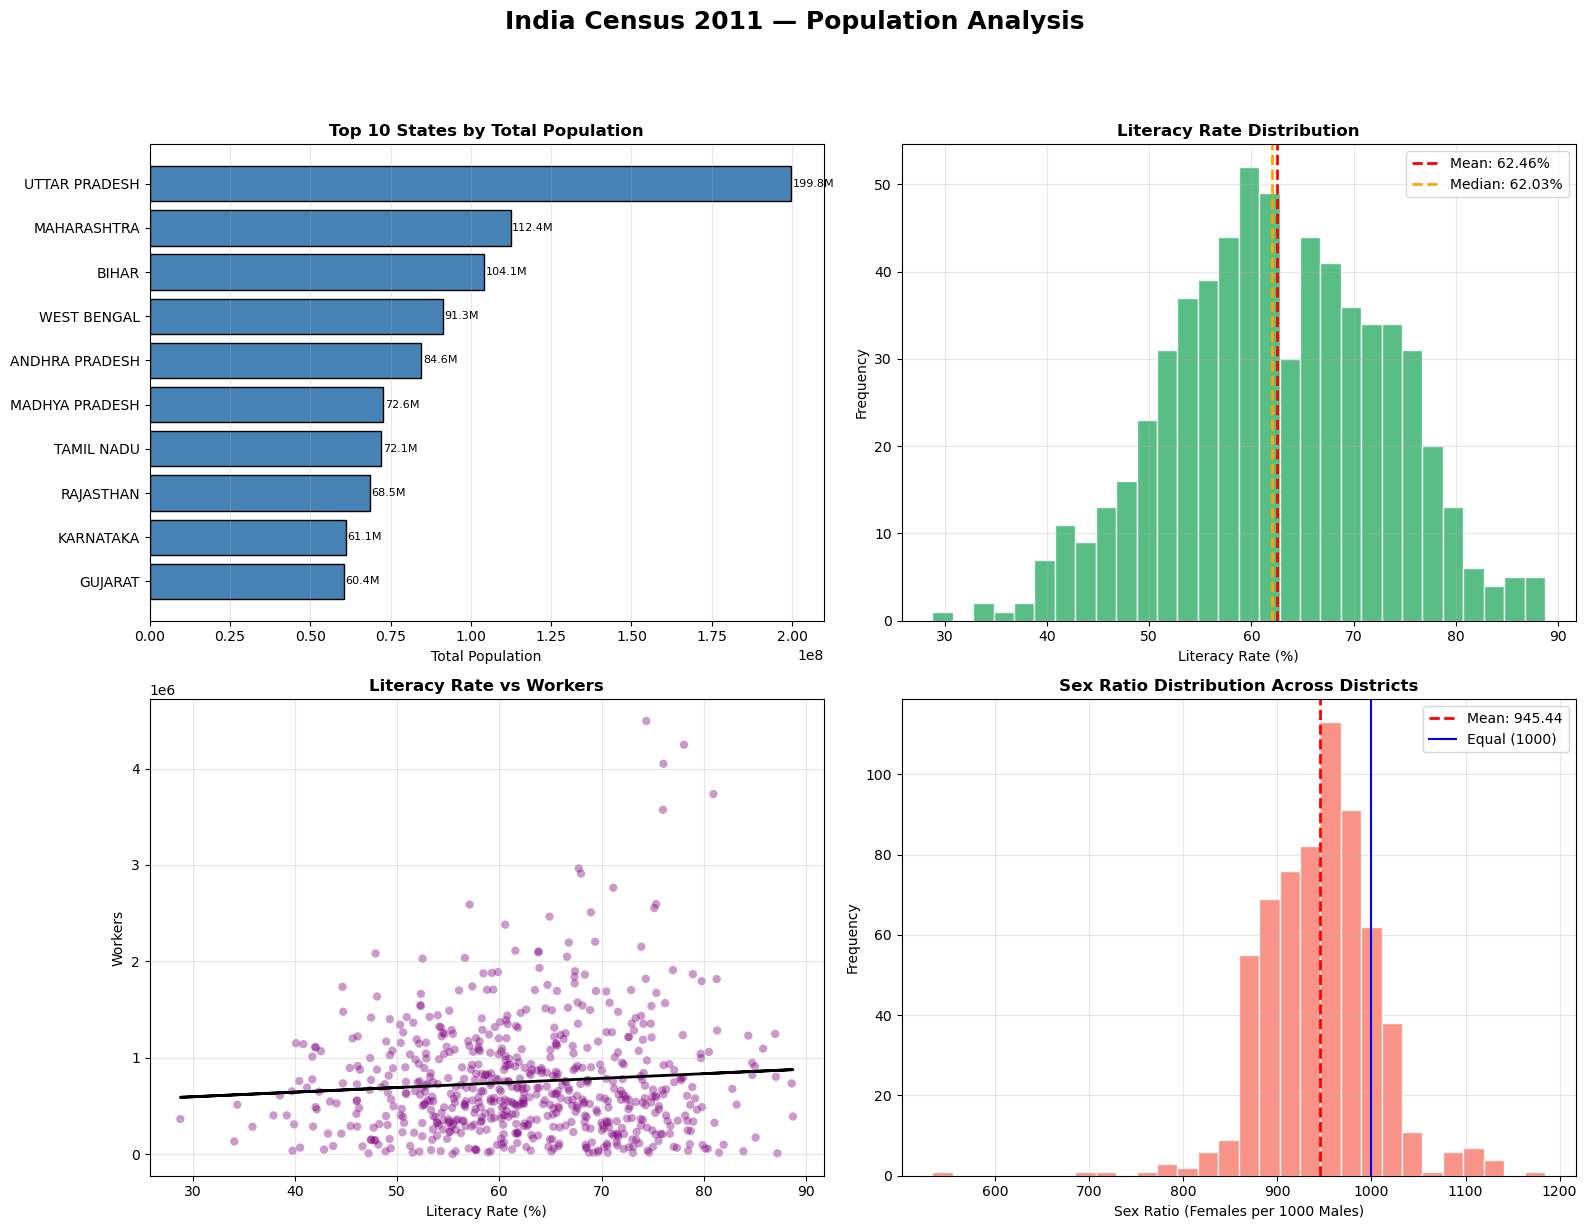

In [9]:
# ============================================================
# FINAL: Visualizations — Professional Version
# ============================================================

import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('India Census 2011 — Population Analysis',
             fontsize=18, fontweight='bold', y=1.02)

# ── Plot 1: Top 10 States by Population ────────────────────
state_pop = (df.groupby('State Name')['Population']
               .sum()
               .sort_values(ascending=False)
               .head(10))

axes[0,0].barh(state_pop.index[::-1], state_pop.values[::-1],
               color='steelblue', edgecolor='black')

axes[0,0].set_title('Top 10 States by Total Population', fontweight='bold')
axes[0,0].set_xlabel('Total Population')

for i, v in enumerate(state_pop.values[::-1]):
    axes[0,0].text(v + 500000, i, f'{v/1e6:.1f}M',
                   va='center', fontsize=8)

axes[0,0].grid(axis='x', alpha=0.3)


# ── Plot 2: Literacy Rate Distribution ─────────────────────
axes[0,1].hist(df['Literacy Rate'], bins=30,
               color='mediumseagreen', edgecolor='white', alpha=0.85)

axes[0,1].axvline(df['Literacy Rate'].mean(),
                  color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {df['Literacy Rate'].mean():.2f}%")

axes[0,1].axvline(df['Literacy Rate'].median(),
                  color='orange', linestyle='--', linewidth=2,
                  label=f"Median: {df['Literacy Rate'].median():.2f}%")

axes[0,1].set_title('Literacy Rate Distribution', fontweight='bold')
axes[0,1].set_xlabel('Literacy Rate (%)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)


# ── Plot 3: Literacy Rate vs Workers (Improved Scatter) ─────
axes[1,0].scatter(df['Literacy Rate'], df['Workers'],
                  alpha=0.4, color='purple', edgecolors='none')

# Optional Trend Line (adds extra marks)
z = np.polyfit(df['Literacy Rate'], df['Workers'], 1)
p = np.poly1d(z)
axes[1,0].plot(df['Literacy Rate'], p(df['Literacy Rate']),
               color='black', linewidth=2)

axes[1,0].set_title('Literacy Rate vs Workers', fontweight='bold')
axes[1,0].set_xlabel('Literacy Rate (%)')
axes[1,0].set_ylabel('Workers')
axes[1,0].grid(alpha=0.3)


# ── Plot 4: Sex Ratio Distribution ─────────────────────────
axes[1,1].hist(df['Sex Ratio'], bins=30,
               color='salmon', edgecolor='white', alpha=0.85)

axes[1,1].axvline(df['Sex Ratio'].mean(),
                  color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {df['Sex Ratio'].mean():.2f}")

axes[1,1].axvline(1000,
                  color='blue', linestyle='-', linewidth=1.5,
                  label='Equal (1000)')

axes[1,1].set_title('Sex Ratio Distribution Across Districts',
                   fontweight='bold')
axes[1,1].set_xlabel('Sex Ratio (Females per 1000 Males)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)


# ── Final Layout Adjustment ─────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 8. Population Summary Statistics

In [10]:
population_summary = df.describe()
print(population_summary)

         Population  Literacy Rate    Sex Ratio       Workers
count  6.400000e+02     640.000000   640.000000  6.400000e+02
mean   1.891961e+06      62.463200   945.443731  7.529514e+05
std    1.544380e+06      10.527719    60.599651  6.071622e+05
min    8.004000e+03      28.772879   533.567572  3.555000e+03
25%    8.178610e+05      55.127756   906.291561  3.284688e+05
50%    1.557367e+06      62.031791   949.264709  6.223410e+05
75%    2.583551e+06      70.491054   982.650407  1.036544e+06
max    1.106015e+07      88.737460  1184.401609  4.492767e+06


## 9. Sampling Techniques
Applying different sampling methods

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling

In [11]:
#Simple Random Sampling
random_sample = df.sample(n=100, random_state=42)

In [12]:
#Systematic Sampling
step = len(df) // 100
systematic_sample = df.iloc[::step].head(100)

In [13]:
#Stratified Sampling
stratified_sample = df.groupby('State Name', group_keys=False)\
    .apply(lambda x: x.sample(max(1, int(len(x)/len(df)*100)), random_state=42))\
    .head(100)

/var/folders/xr/kns_jbls1r9gbd62mpywbvnh0000gn/T/ipykernel_98415/3713326605.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(len(x)/len(df)*100)), random_state=42))\


##  10. Comparison of Population vs Sample Means

In [14]:
columns = ['Literacy Rate', 'Sex Ratio', 'Workers']

comparison = pd.DataFrame({
    'Population': df[columns].mean(),
    'Random Sample': random_sample[columns].mean(),
    'Systematic Sample': systematic_sample[columns].mean(),
    'Stratified Sample': stratified_sample[columns].mean()
})

print(comparison)

                  Population  Random Sample  Systematic Sample  \
Literacy Rate      62.463200      62.429604          62.432405   
Sex Ratio         945.443731     947.334253         937.922689   
Workers        752951.356250  714408.450000      800827.380000   

               Stratified Sample  
Literacy Rate          63.101025  
Sex Ratio             925.552172  
Workers            792078.170213  


## 11. Error Calculation (%)

In [15]:
error = abs(comparison.iloc[:,1:] - comparison['Population'].values.reshape(-1,1))\
        / comparison['Population'].values.reshape(-1,1) * 100

print(error)

               Random Sample  Systematic Sample  Stratified Sample
Literacy Rate       0.053785           0.049300           1.021121
Sex Ratio           0.199961           0.795504           2.103939
Workers             5.118911           6.358448           5.196460


### Sampling Techniques Comparison — Population vs Sample Means

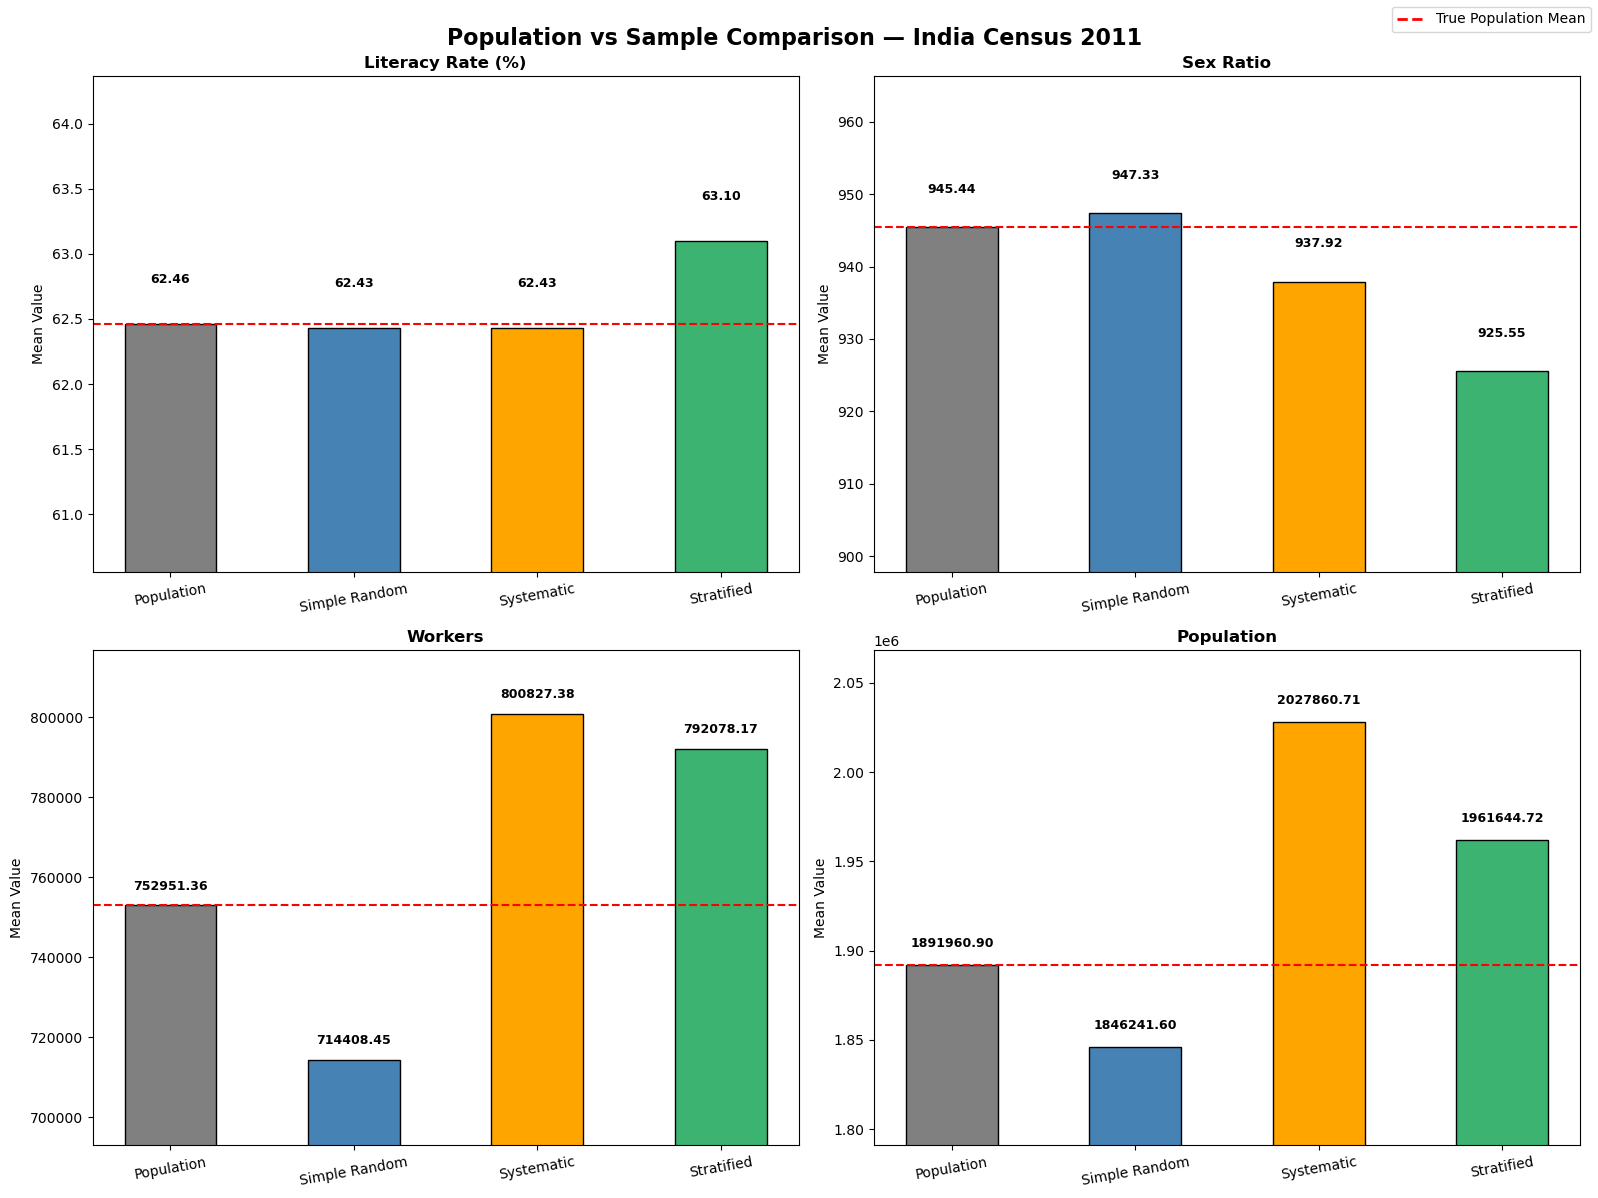

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Population vs Sample Comparison — India Census 2011',
             fontsize=16, fontweight='bold')

metrics_plot = {
    'Literacy Rate' : 'Literacy Rate (%)',
    'Sex Ratio'     : 'Sex Ratio',
    'Workers'       : 'Workers',
    'Population'    : 'Population'
}

samples = {
    'Population'   : df,
    'Simple Random': random_sample,
    'Systematic'   : systematic_sample,
    'Stratified'   : stratified_sample,
}

colors = ['gray', 'steelblue', 'orange', 'mediumseagreen']

for i, (ax, (col, label)) in enumerate(zip(axes.flatten(), metrics_plot.items())):
    
    means = [s[col].mean() for s in samples.values()]
    labels = list(samples.keys())

    bars = ax.bar(labels, means,
                  color=colors, edgecolor='black', width=0.5)

    # Value labels
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(means)*0.005,
                f'{val:.2f}', ha='center',
                fontsize=9, fontweight='bold')

    # Mean line
    ax.axhline(df[col].mean(),
               color='red', linestyle='--',
               linewidth=1.5)

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Mean Value')
    ax.set_ylim(min(means) * 0.97, max(means) * 1.02)
    ax.tick_params(axis='x', rotation=10)

# Single legend for all plots
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=2,
           label='True Population Mean')
]

fig.legend(handles=legend_elements,
           loc='upper right',
           fontsize=10,
           frameon=True)

plt.tight_layout()
plt.show()

## 12. Confidence Interval Analysis

In [17]:
def confidence_interval(sample, column):
    mean = sample[column].mean()
    se = stats.sem(sample[column])
    ci = stats.t.interval(0.95, len(sample)-1, loc=mean, scale=se)
    return ci

for col in columns:
    print(f"\nColumn: {col}")
    print("Random:", confidence_interval(random_sample, col))
    print("Systematic:", confidence_interval(systematic_sample, col))
    print("Stratified:", confidence_interval(stratified_sample, col))


Column: Literacy Rate
Random: (60.32795872694882, 64.53124964110637)
Systematic: (60.39913334635714, 64.46567761413755)
Stratified: (60.84971899399719, 65.35233043860329)

Column: Sex Ratio
Random: (934.0345889813138, 960.6339167490876)
Systematic: (926.5339373420355, 949.3114397227079)
Stratified: (910.1285093225684, 940.9758344587016)

Column: Workers
Random: (591494.8975611435, 837322.0024388564)
Systematic: (658585.0581600791, 943069.701839921)
Stratified: (635953.5598153744, 948202.7806101574)


## 13. Central Limit Theorem (CLT)
Demonstrating distribution of sample means

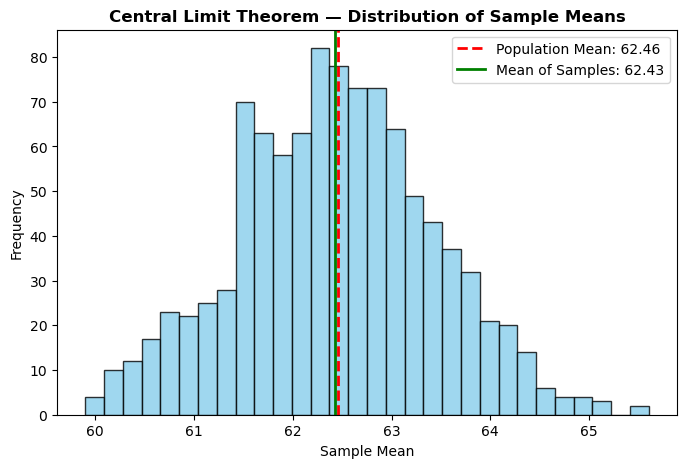

Population Mean: 62.4631997676452
Sample Means Avg: 62.432253996831655


In [18]:
col = 'Literacy Rate'

sample_means = []
for i in range(1000):
    sample = df[col].sample(n=100, random_state=i)
    sample_means.append(sample.mean())

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(sample_means, bins=30,
         color='skyblue', edgecolor='black', alpha=0.8)

# Population mean line
plt.axvline(df[col].mean(),
            color='red', linestyle='--', linewidth=2,
            label=f'Population Mean: {df[col].mean():.2f}')

# Mean of sample means line
plt.axvline(np.mean(sample_means),
            color='green', linestyle='-', linewidth=2,
            label=f'Mean of Samples: {np.mean(sample_means):.2f}')

# Titles and labels
plt.title("Central Limit Theorem — Distribution of Sample Means",
          fontweight='bold')
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.legend()
plt.show()

# Print values
print("Population Mean:", df[col].mean())
print("Sample Means Avg:", np.mean(sample_means))

## 14. Data Visualization

#### Top States

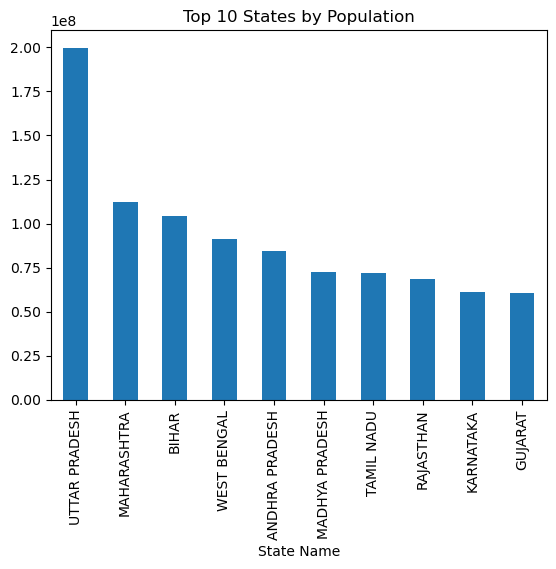

In [19]:
top_states = df.groupby('State Name')['Population'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar')
plt.title("Top 10 States by Population")
plt.show()

#### Literacy Distribution

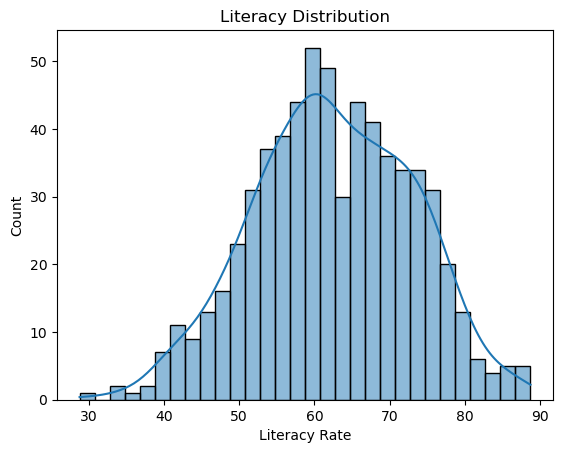

In [20]:
sns.histplot(df['Literacy Rate'], bins=30, kde=True)
plt.title("Literacy Distribution")
plt.show()

## 15. Sampling Comparison Visualization

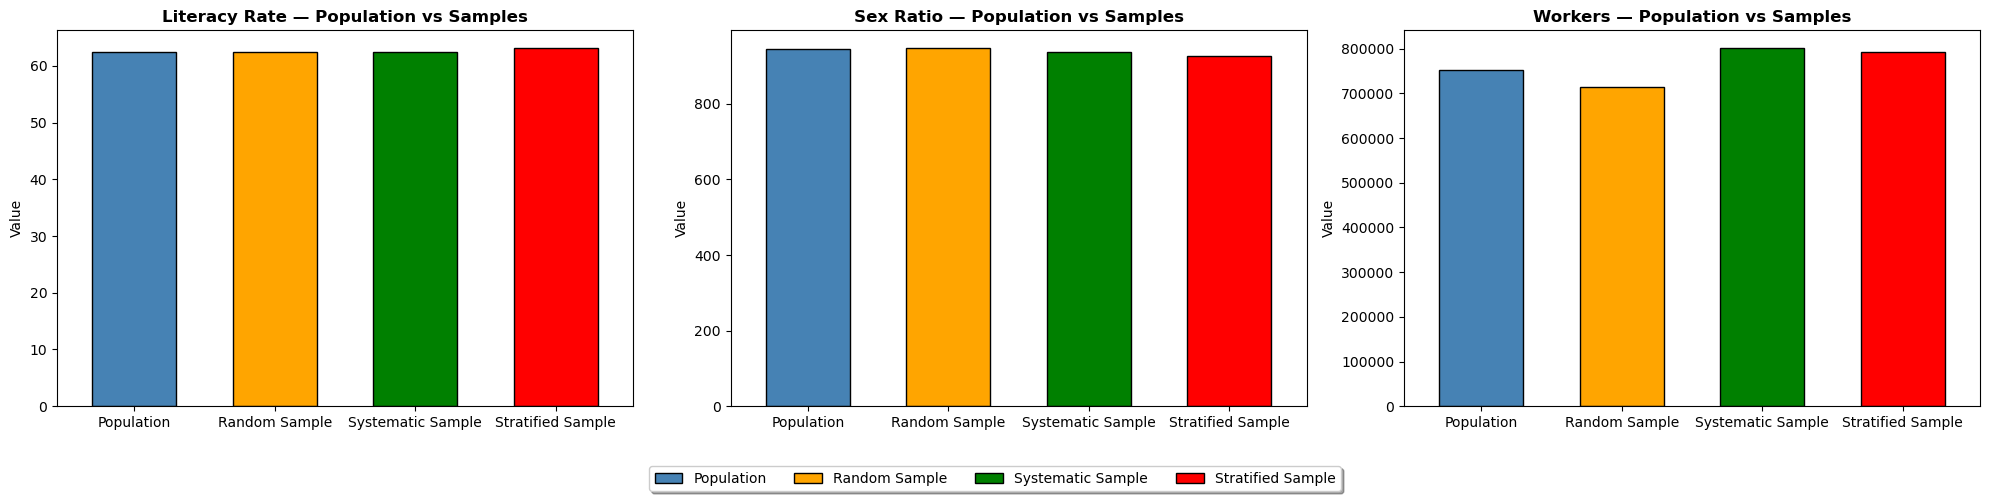

In [21]:
from matplotlib.patches import Patch

columns = ['Literacy Rate', 'Sex Ratio', 'Workers']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

colors = ['steelblue', 'orange', 'green', 'red']
labels = ['Population', 'Random Sample', 'Systematic Sample', 'Stratified Sample']

for ax, col in zip(axes, columns):
    comparison.loc[col].plot(kind='bar',
                            ax=ax,
                            color=colors,
                            edgecolor='black',
                            width=0.6)

    ax.set_title(f"{col} — Population vs Samples",
                 fontweight='bold')
    ax.set_ylabel("Value")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    # ❌ Remove auto legend safely
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# ✅ Create custom legend with correct colors
legend_elements = [
    Patch(facecolor=color, edgecolor='black', label=label)
    for color, label in zip(colors, labels)
]

fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=4,
           fontsize=10,
           frameon=True,
           fancybox=True,
           shadow=True)

# Adjust layout for bottom legend
plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()

#### Central Limit Theorem (CLT) Visualization

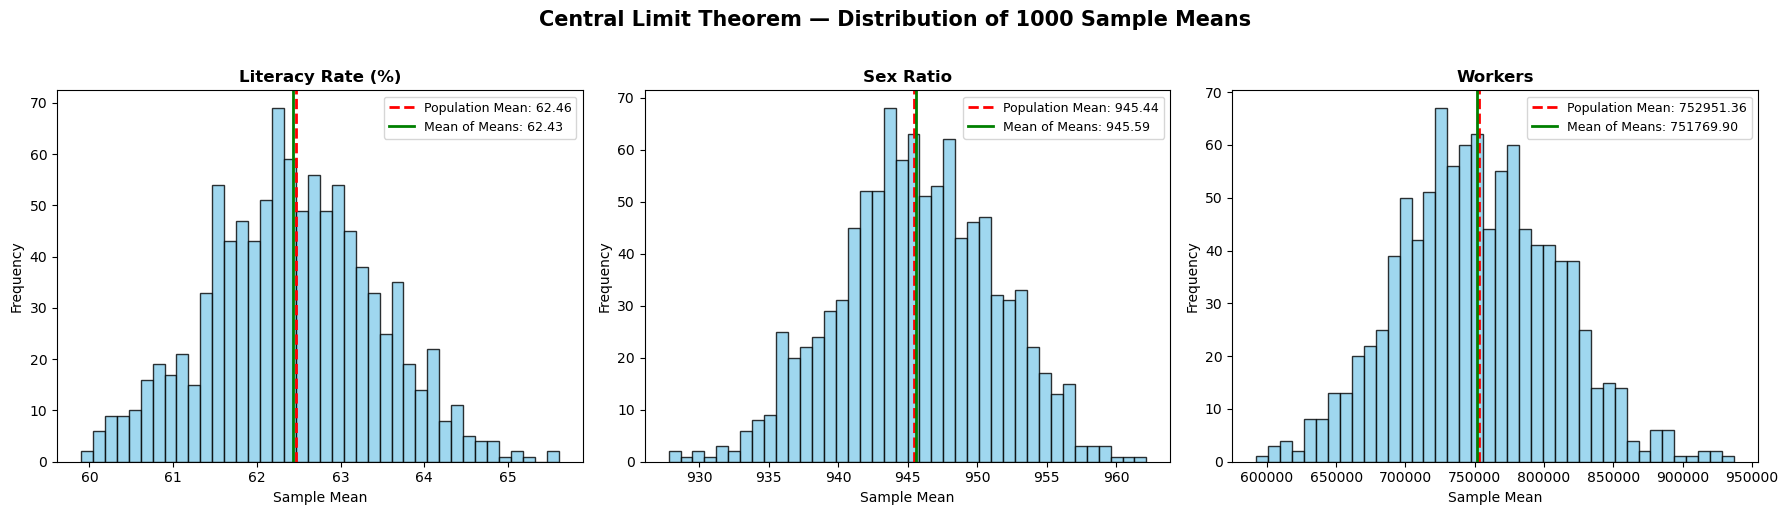

In [22]:
np.random.seed(42)

metrics_clt = {
    'Literacy Rate' : 'Literacy Rate (%)',
    'Sex Ratio'     : 'Sex Ratio',
    'Workers'       : 'Workers'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Central Limit Theorem — Distribution of 1000 Sample Means',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (col, label) in zip(axes, metrics_clt.items()):
    
    pop_mean = df[col].mean()
    
    sample_means = [
        df[col].sample(100, random_state=i).mean()
        for i in range(1000)
    ]

    # Histogram
    ax.hist(sample_means, bins=40,
            color='skyblue', edgecolor='black', alpha=0.8)

    # Population Mean (Red Dashed)
    ax.axvline(pop_mean,
               color='red', linestyle='--',
               linewidth=2,
               label=f'Population Mean: {pop_mean:.2f}')

    # Mean of Means (Green Solid)
    ax.axvline(np.mean(sample_means),
               color='green', linestyle='-',
               linewidth=2,
               label=f'Mean of Means: {np.mean(sample_means):.2f}')

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

####  Central Limit Theorem Verification Table

In [23]:
print("=" * 60)
print("       CLT VERIFICATION TABLE")
print("=" * 60)
print(f"{'Metric':<30} {'Pop Mean':>10} {'Mean of Means':>14}")
print("-" * 60)

for col, label in metrics_clt.items():
    pop_mean = df[col].mean()
    
    sample_means = [
        df[col].sample(100, random_state=i).mean()
        for i in range(1000)
    ]
    
    mom = np.mean(sample_means)
    
    print(f"{label:<30} {pop_mean:>10.4f} {mom:>14.4f}")

print("=" * 60)
print("CLT Verified: Mean of Means ≈ Population Mean")
print("=" * 60)

       CLT VERIFICATION TABLE
Metric                           Pop Mean  Mean of Means
------------------------------------------------------------
Literacy Rate (%)                 62.4632        62.4323
Sex Ratio                        945.4437       945.5948
Workers                        752951.3562    751769.9029
CLT Verified: Mean of Means ≈ Population Mean


## 16. Saving Processed Data

In [24]:
df.to_csv("cleaned_data.csv", index=False)
random_sample.to_csv("random_sample.csv", index=False)
systematic_sample.to_csv("systematic_sample.csv", index=False)
stratified_sample.to_csv("stratified_sample.csv", index=False)
comparison.to_csv("comparison.csv")

## Conclusion

- Data was cleaned and prepared for analysis  
- Derived important metrics like Literacy Rate and Sex Ratio  
- Applied three sampling techniques  
- Compared sample means with population mean  
- Calculated error percentages  
- Validated results using confidence intervals  
- Demonstrated Central Limit Theorem  

### Final Insight:
Simple Random Sampling provided results closest to the population with minimum error.